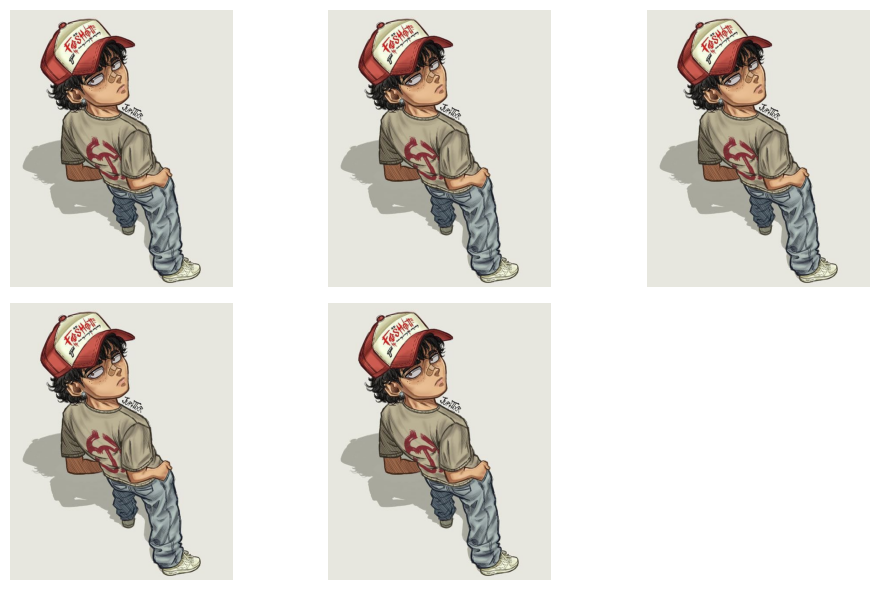

(640, 514, 3)
uint8


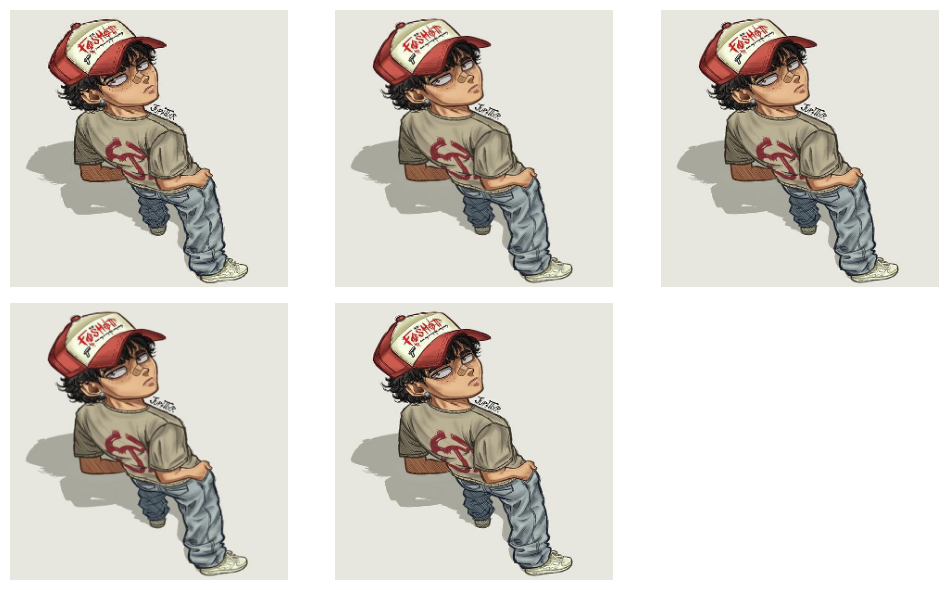

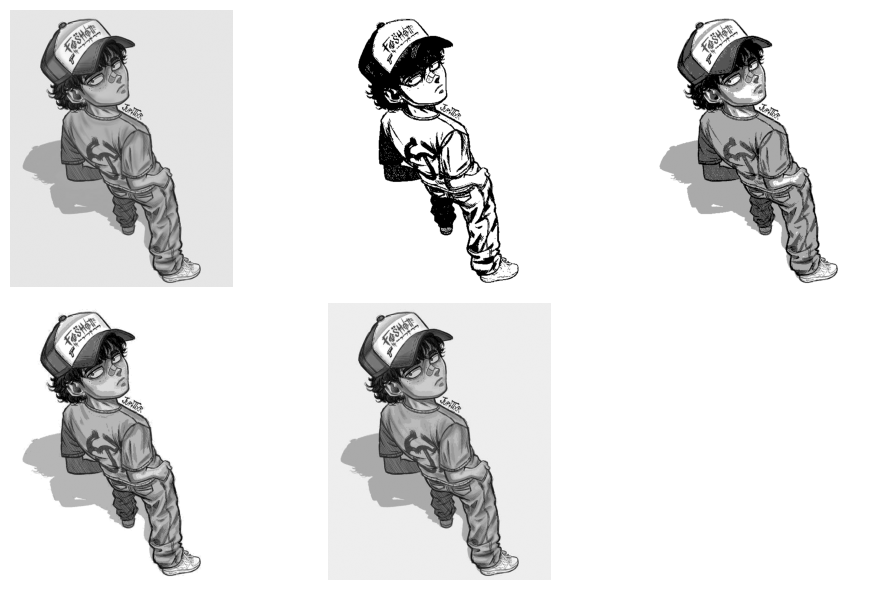

(640, 514, 3)
[(4, 5), (6, 5), (5, 4), (5, 6)]
[(4, 5), (6, 5), (5, 4), (5, 6), (4, 4), (4, 6), (6, 4), (6, 6)]


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import imageio.v2 as imageio
from skimage import io as skio

img_path = r"C:\Users\X\Desktop\wallpaper.jpg"

img_cv = cv2.imread(img_path)
img_cv_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)

img_pil = Image.open(img_path)
img_mp = plt.imread(img_path)
img_io = imageio.imread(img_path)
img_sk = skio.imread(img_path)

plt.figure(figsize=(10,6))

plt.subplot(2,3,1)
plt.imshow(img_cv_rgb)
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(img_pil)
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(img_mp)
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(img_io)
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(img_sk)
plt.axis("off")

plt.tight_layout()
plt.show()

print(img_cv.shape)
print(img_cv.dtype)

resize_shape = (300, 300)

nearest = cv2.resize(img_cv, resize_shape, interpolation=cv2.INTER_NEAREST)
bilinear = cv2.resize(img_cv, resize_shape, interpolation=cv2.INTER_LINEAR)
bicubic = cv2.resize(img_cv, resize_shape, interpolation=cv2.INTER_CUBIC)
area = cv2.resize(img_cv, resize_shape, interpolation=cv2.INTER_AREA)
lanczos = cv2.resize(img_cv, resize_shape, interpolation=cv2.INTER_LANCZOS4)

imgs = [nearest, bilinear, bicubic, area, lanczos]

plt.figure(figsize=(10,6))

for i in range(5):
    plt.subplot(2,3,i+1)
    plt.imshow(cv2.cvtColor(imgs[i], cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()

def quantize_image(img, levels):
    step = 256 // levels
    return (img // step) * step

gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)

q2 = quantize_image(gray, 2)
q4 = quantize_image(gray, 4)
q8 = quantize_image(gray, 8)
q16 = quantize_image(gray, 16)

imgs = [gray, q2, q4, q8, q16]

plt.figure(figsize=(10,6))

for i in range(5):
    plt.subplot(2,3,i+1)
    plt.imshow(imgs[i], cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

def n_4(x, y):
    return [(x-1,y), (x+1,y), (x,y-1), (x,y+1)]

def n_8(x, y):
    return [(x-1,y),(x+1,y),(x,y-1),(x,y+1),(x-1,y-1),(x-1,y+1),(x+1,y-1),(x+1,y+1)]

print(img_cv.shape)
print(n_4(5,5))
print(n_8(5,5)) 